# Group Proposed Project: IoT-Driven Smart Parking System

# 0. Data Preparation

## 0.1 Integration of IoT Carpark Data and Carpark Metadata

In this subsection, we establish the analytical foundation by merging high-frequency IoT sensor data with static carpark metadata. This integration allows us to transition from observing isolated availability numbers to understanding the spatial and policy-driven contexts of Singapore's parking ecosystem.

**Datasets Utilized**:
   1. **Dynamic IoT Dataset (`carpark_data_typeC_...csv`)**: This file contains the time-series records of available lots for Type C parking spaces across Singapore. It captures real-time fluctuations driven by driver behavior and urban mobility patterns.
   2. **Carpark Metadata (`HDBCarparkInformation.csv`)**: This dataset provides the physical and administrative context for each facility, including precise geographical coordinates (SVY21 system), parking types (e.g., Basement, Surface), and specific policies such as "Free Parking" on Sundays.

In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

In [220]:
df_park = pd.read_csv('datasets/carpark_data_typeC_2026-01-01_to_2026-03-27.csv')
df_park['data_snapshot_time'] = pd.to_datetime(df_park['data_snapshot_time'])
df_park = df_park[df_park['data_snapshot_time'].dt.month.isin([1, 2])].copy()

df_park_info = pd.read_csv('datasets/HDBCarparkInformation.csv')
df_park_info = df_park_info.rename(columns={'car_park_no': 'carpark_number'})

In [221]:
print(f"df_park: {df_park.shape} , df_park_info: {df_park_info.shape}")

df_park: (2786081, 6) , df_park_info: (2263, 12)


In [222]:
df_park.head()

,carpark_number,update_datetime,total_lots,lot_type,lots_available,data_snapshot_time
0,HE12,2025-12-31T23:59:51,105,C,31,2026-01-01 00:01:00
1,HLM,2025-12-31T23:59:52,583,C,433,2026-01-01 00:01:00
2,RHM,2025-12-31T23:59:51,329,C,160,2026-01-01 00:01:00
3,BM29,2025-12-31T23:59:36,96,C,66,2026-01-01 00:01:00
4,Q81,2025-12-31T23:59:47,97,C,84,2026-01-01 00:01:00


In [223]:
df_park_info.head()

,carpark_number,address,x_coord,y_coord,car_park_type,type_of_parking_system,short_term_parking,free_parking,night_parking,car_park_decks,gantry_height,car_park_basement
0,ACB,BLK 270/271 ALBERT CENTRE BASEMENT CAR PARK,30314.7936,31490.4942,BASEMENT CAR PARK,ELECTRONIC PARKING,WHOLE DAY,NO,YES,1,1.8,Y
1,ACM,BLK 98A ALJUNIED CRESCENT,33758.4143,33695.5198,MULTI-STOREY CAR PARK,ELECTRONIC PARKING,WHOLE DAY,SUN & PH FR 7AM-10.30PM,YES,5,2.1,N
2,AH1,BLK 101 JALAN DUSUN,29257.7203,34500.3599,SURFACE CAR PARK,ELECTRONIC PARKING,WHOLE DAY,SUN & PH FR 7AM-10.30PM,YES,0,0.0,N
3,AK19,BLOCK 253 ANG MO KIO STREET 21,28185.4359,39012.6664,SURFACE CAR PARK,COUPON PARKING,7AM-7PM,NO,NO,0,0.0,N
4,AK31,BLK 302/348 ANG MO KIO STREET 31,29482.0290,38684.1754,SURFACE CAR PARK,COUPON PARKING,NO,NO,NO,0,0.0,N


In [224]:
df_park_full = pd.merge(df_park, df_park_info, on='carpark_number', how='inner')

# 优化数据集内存占用
cat_cols = ['car_park_type', 'type_of_parking_system', 'free_parking',
            'short_term_parking', 'night_parking', 'car_park_basement']
for col in cat_cols:
    if col in df_park_full.columns:
        df_park_full[col] = df_park_full[col].astype('category')

df_park_full['occupancy_rate'] = (df_park_full['total_lots'] - df_park_full['lots_available']) / df_park_full[
    'total_lots']

In [225]:
print(f"df_park_full: {df_park_full.shape}")
df_park_full.info(memory_usage='deep')
df_park_full.head()

df_park_full: (2781032, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781032 entries, 0 to 2781031
Data columns (total 18 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   carpark_number          object        
 1   update_datetime         object        
 2   total_lots              int64         
 3   lot_type                object        
 4   lots_available          int64         
 5   data_snapshot_time      datetime64[ns]
 6   address                 object        
 7   x_coord                 float64       
 8   y_coord                 float64       
 9   car_park_type           category      
 10  type_of_parking_system  category      
 11  short_term_parking      category      
 12  free_parking            category      
 13  night_parking           category      
 14  car_park_decks          int64         
 15  gantry_height           float64       
 16  car_park_basement       category      
 17  occupancy_rate    

,carpark_number,update_datetime,total_lots,lot_type,lots_available,data_snapshot_time,address,x_coord,y_coord,car_park_type,type_of_parking_system,short_term_parking,free_parking,night_parking,car_park_decks,gantry_height,car_park_basement,occupancy_rate
0,HE12,2025-12-31T23:59:51,105,C,31,2026-01-01 00:01:00,BLK 78/81 REDHILL LANE,26367.5806,30069.2434,SURFACE CAR PARK,ELECTRONIC PARKING,WHOLE DAY,SUN & PH FR 7AM-10.30PM,YES,0,4.50,N,0.704762
1,HLM,2025-12-31T23:59:52,583,C,433,2026-01-01 00:01:00,BLK 533A HONG LIM MSCP,29354.6692,29687.5080,MULTI-STOREY CAR PARK,ELECTRONIC PARKING,WHOLE DAY,NO,YES,11,1.90,N,0.257290
2,RHM,2025-12-31T23:59:51,329,C,160,2026-01-01 00:01:00,BLK 88A REDHILL CLOSE,26359.4531,29876.1692,MULTI-STOREY CAR PARK,ELECTRONIC PARKING,WHOLE DAY,SUN & PH FR 7AM-10.30PM,YES,10,1.90,N,0.513678
3,BM29,2025-12-31T23:59:36,96,C,66,2026-01-01 00:01:00,BLK 163 BUKIT MERAH CENTRAL,26194.9184,29563.3295,BASEMENT CAR PARK,ELECTRONIC PARKING,WHOLE DAY,NO,YES,1,2.00,Y,0.312500
4,Q81,2025-12-31T23:59:47,97,C,84,2026-01-01 00:01:00,BLK 43 HOLLAND DRIVE,23531.2041,32206.3235,SURFACE CAR PARK,ELECTRONIC PARKING,WHOLE DAY,NO,YES,0,9.99,N,0.134021


In [226]:
# 清理内存占用
del df_park
gc.collect()

23254

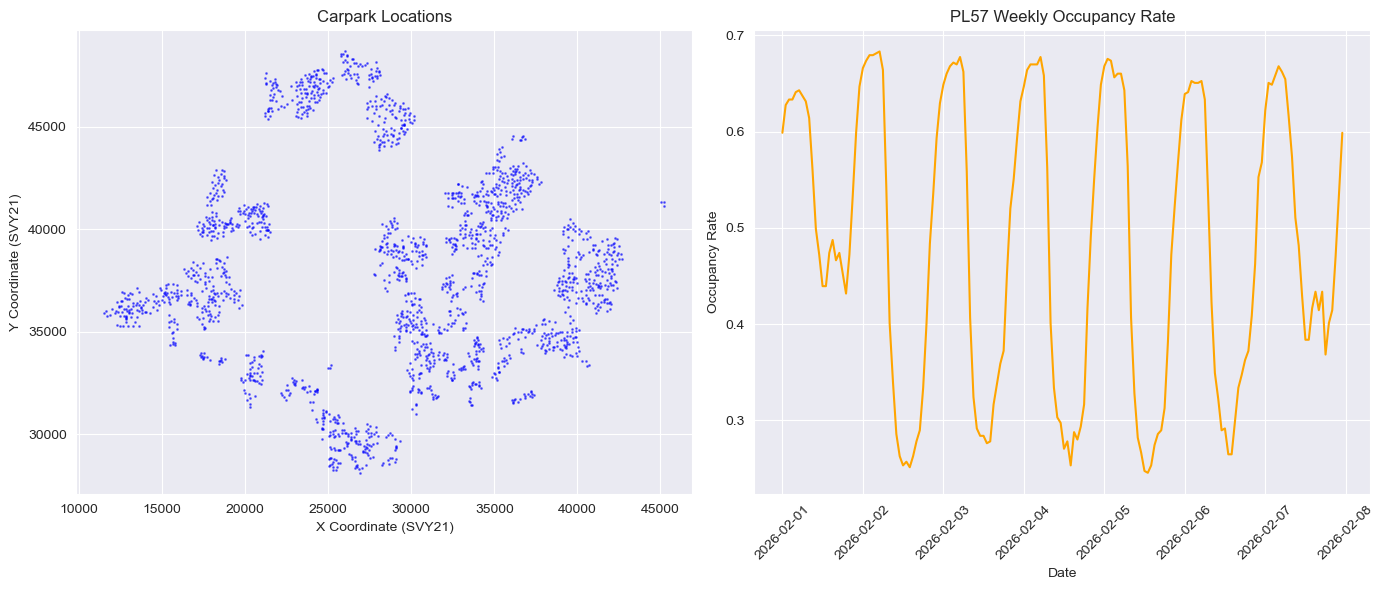

In [227]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sample_geo = df_park_full.drop_duplicates('carpark_number')
plt.scatter(sample_geo['x_coord'], sample_geo['y_coord'], s=1, alpha=0.5, color='blue')
plt.title('Carpark Locations')
plt.xlabel('X Coordinate (SVY21)')
plt.ylabel('Y Coordinate (SVY21)')

plt.subplot(1, 2, 2)
test_pl57 = df_park_full[df_park_full['carpark_number'] == 'PL57'].sort_values('data_snapshot_time')
feb_week = test_pl57[(test_pl57['data_snapshot_time'] >= '2026-02-01') &
                     (test_pl57['data_snapshot_time'] < '2026-02-08')]
plt.plot(feb_week['data_snapshot_time'], feb_week['occupancy_rate'], color='orange')
plt.title('PL57 Weekly Occupancy Rate')
plt.xlabel('Date')
plt.ylabel('Occupancy Rate')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 0.2 Integration of Public Transport Proximity Data

In this subsection, we incorporate the geographical distribution of Singapore's rail network (MRT and LRT) to examine the relationship between carpark occupancy and public transport accessibility. By mapping these transit nodes, we can calculate the "last-mile" distance from each carpark to the nearest station, providing a critical spatial feature for our machine learning analysis.

**Datasets Utilized**:
   1. **Public Transport Nodes (`Singapore_MRT_LRT_Stations.csv`)**: This dataset contains the precise geographical locations (WGS84 Latitude/Longitude) of all MRT and LRT stations, along with their station codes, names, and operational lines.

### Implementation Workflow:

1. **Coordinate Alignment (WGS84 to SVY21)**:
   While the MRT dataset utilizes the global WGS84 (Latitude/Longitude) system, the carpark metadata is recorded in Singapore's national SVY21 (X/Y in meters) projection system. To ensure spatial consistency, we implemented a mathematical transformation using Redfearn's equations to convert the transit nodes into the SVY21 coordinate system. This alignment allows for direct Euclidean distance calculations between parking facilities and transit hubs.

2. **Proximity Feature Engineering**:
   Using the aligned coordinates, we computed the distance from every unique carpark to its nearest MRT/LRT station. This "Proximity to Transit" metric is hypothesized to be a significant driver of occupancy rates, especially for "Park and Ride" behavior during peak commuting hours.

3. **Data Augmentation**:
   The resulting proximity feature (`dist_to_nearest_mrt`) was merged into the primary `df_park_full` dataset. By integrating this spatial context into our 2.7-million-record IoT time-series, we enable the model to capture how geographical convenience influences real-time parking demand fluctuations.

In [228]:
df_mrt = pd.read_csv('datasets/Singapore_MRT_LRT_Stations.csv')
print(f"df_mrt shape: {df_mrt.shape}")
df_mrt.head()

df_mrt shape: (213, 6)


,Station_Code,Station_Name,Line,Latitude,Longitude,Postal Code
0,EW24/NS1,Jurong East,North-South Line,1.3332,103.7422,609431
1,NS2,Bukit Batok,North-South Line,1.3490,103.7496,659958
2,NS3,Bukit Gombak,North-South Line,1.3587,103.7517,659961
3,NS4/BP1,Choa Chu Kang,North-South Line,1.3854,103.7443,689812
4,NS5,Yew Tee,North-South Line,1.3970,103.7473,768830


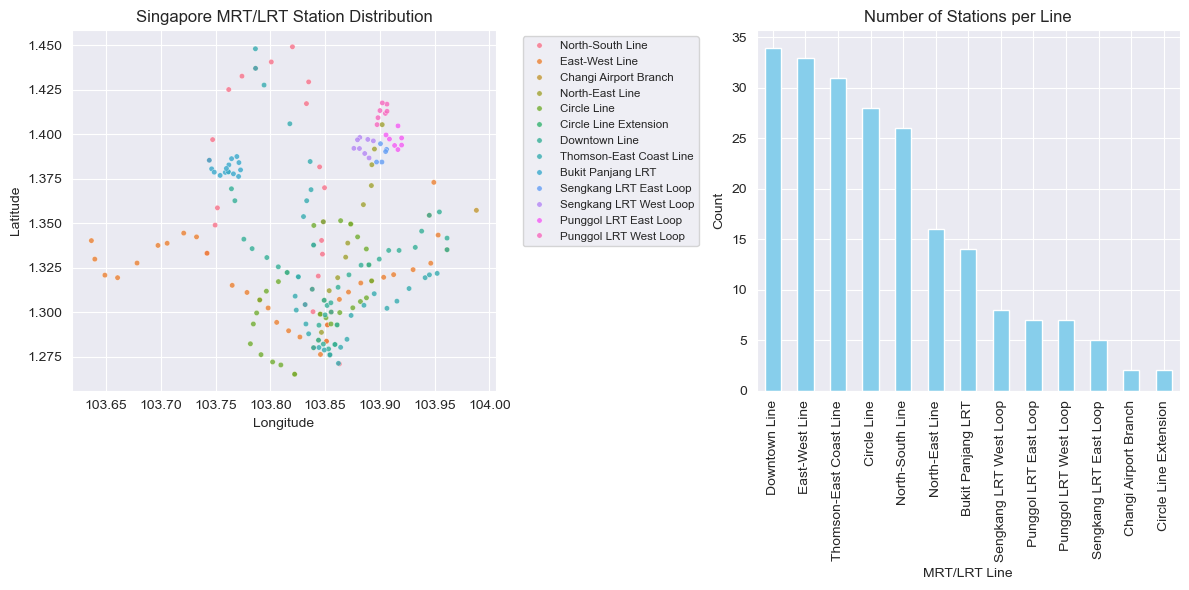

Missing coordinates:
Latitude     0
Longitude    0
dtype: int64


In [229]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_mrt, x='Longitude', y='Latitude', hue='Line', s=15, alpha=0.8)
plt.title('Singapore MRT/LRT Station Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.subplot(1, 2, 2)
df_mrt['Line'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Number of Stations per Line')
plt.xlabel('MRT/LRT Line')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

missing_coords = df_mrt[['Latitude', 'Longitude']].isnull().sum()
print(f"Missing coordinates:\n{missing_coords}")

In [230]:
import numpy as np
import math
from scipy.spatial.distance import cdist

In [231]:
def wgs84_to_svy21(lat, lon):
    # 新加坡 SVY21 投影参数
    a = 6378137.0
    f = 1 / 298.257223563
    oLat = 1.366666
    oLon = 103.833333
    oN = 38744.577
    oE = 28001.642
    k = 1.0

    b = a * (1 - f)
    e2 = (a ** 2 - b ** 2) / a ** 2
    n = (a - b) / (a + b)
    n2, n3, n4 = n ** 2, n ** 3, n ** 4

    latRad = math.radians(lat)
    lonRad = math.radians(lon)
    oLatRad = math.radians(oLat)
    oLonRad = math.radians(oLon)

    A = a / (1 + n) * (1 + 1 / 4 * n2 + 1 / 64 * n4)
    M = A * ((1 + n + 5 / 4 * n2 + 5 / 4 * n3) * (latRad - oLatRad) -
             (3 / 2 * n + 3 / 2 * n2 + 21 / 8 * n3) * math.sin(latRad - oLatRad) * math.cos(latRad + oLatRad) +
             (15 / 8 * n2 + 15 / 8 * n3) * math.sin(2 * (latRad - oLatRad)) * math.cos(2 * (latRad + oLatRad)))

    rho = a * (1 - e2) / pow(1 - e2 * math.sin(latRad) ** 2, 1.5)
    nu = a / math.sqrt(1 - e2 * math.sin(latRad) ** 2)
    psi = nu / rho
    t = math.tan(latRad)
    w = lonRad - oLonRad

    term1_n = (w ** 2 / 2) * nu * math.sin(latRad) * math.cos(latRad)
    term2_n = (w ** 4 / 24) * nu * math.sin(latRad) * math.cos(latRad) ** 3 * (4 * psi ** 2 + psi - t ** 2)
    term3_n = (w ** 6 / 720) * nu * math.sin(latRad) * math.cos(latRad) ** 5 * (
                8 * psi ** 4 * (11 - 24 * t ** 2) - 28 * psi ** 3 * (1 - 6 * t ** 2))
    N = oN + k * (M + term1_n + term2_n + term3_n)

    term1_e = w * nu * math.cos(latRad)
    term2_e = (w ** 3 / 6) * nu * math.cos(latRad) ** 3 * (psi - t ** 2)
    term3_e = (w ** 5 / 120) * nu * math.cos(latRad) ** 5 * (
                4 * psi ** 3 * (1 - 6 * t ** 2) + psi ** 2 * (1 + 8 * t ** 2) - psi * 2 * t ** 2 + t ** 4)
    E = oE + k * (term1_e + term2_e + term3_e)

    return E, N

In [232]:
df_mrt['x_coord'], df_mrt['y_coord'] = zip(*df_mrt.apply(
    lambda row: wgs84_to_svy21(row['Latitude'], row['Longitude']), axis=1
))

print("MRT Stations coordinate transformation completed using math formulas.")
print(df_mrt[['Station_Name', 'x_coord', 'y_coord']].head())

MRT Stations coordinate transformation completed using math formulas.
    Station_Name       x_coord       y_coord
0    Jurong East  17859.486434  35028.664945
1    Bukit Batok  18683.089883  36783.086081
2   Bukit Gombak  18916.832806  37860.177421
3  Choa Chu Kang  18093.407565  40825.006347
4        Yew Tee  18427.316221  42113.071849


In [233]:
unique_parks = df_park_full[['carpark_number', 'x_coord', 'y_coord']].drop_duplicates().copy()

In [234]:
dist_matrix = cdist(
    unique_parks[['x_coord', 'y_coord']],
    df_mrt[['x_coord', 'y_coord']],
    metric='euclidean'
)

unique_parks['dist_to_nearest_mrt'] = dist_matrix.min(axis=1)

df_park_full = df_park_full.merge(
    unique_parks[['carpark_number', 'dist_to_nearest_mrt']],
    on='carpark_number',
    how='left'
)

print(f"\nFeature extraction complete for {df_park_full.shape[0]} records.")
print(df_park_full[['carpark_number', 'dist_to_nearest_mrt']].describe())


Feature extraction complete for 2781032 records.
       dist_to_nearest_mrt
count         2.781032e+06
mean          6.305155e+02
std           4.149278e+02
min           1.493706e+01
25%           3.257412e+02
50%           5.467421e+02
75%           8.271216e+02
max           3.623255e+03


In [235]:
df_park_full.head()

,carpark_number,update_datetime,total_lots,lot_type,lots_available,data_snapshot_time,address,x_coord,y_coord,car_park_type,type_of_parking_system,short_term_parking,free_parking,night_parking,car_park_decks,gantry_height,car_park_basement,occupancy_rate,dist_to_nearest_mrt
0,HE12,2025-12-31T23:59:51,105,C,31,2026-01-01 00:01:00,BLK 78/81 REDHILL LANE,26367.5806,30069.2434,SURFACE CAR PARK,ELECTRONIC PARKING,WHOLE DAY,SUN & PH FR 7AM-10.30PM,YES,0,4.50,N,0.704762,252.467871
1,HLM,2025-12-31T23:59:52,583,C,433,2026-01-01 00:01:00,BLK 533A HONG LIM MSCP,29354.6692,29687.5080,MULTI-STOREY CAR PARK,ELECTRONIC PARKING,WHOLE DAY,NO,YES,11,1.90,N,0.257290,183.230117
2,RHM,2025-12-31T23:59:51,329,C,160,2026-01-01 00:01:00,BLK 88A REDHILL CLOSE,26359.4531,29876.1692,MULTI-STOREY CAR PARK,ELECTRONIC PARKING,WHOLE DAY,SUN & PH FR 7AM-10.30PM,YES,10,1.90,N,0.513678,383.863752
3,BM29,2025-12-31T23:59:36,96,C,66,2026-01-01 00:01:00,BLK 163 BUKIT MERAH CENTRAL,26194.9184,29563.3295,BASEMENT CAR PARK,ELECTRONIC PARKING,WHOLE DAY,NO,YES,1,2.00,Y,0.312500,636.418787
4,Q81,2025-12-31T23:59:47,97,C,84,2026-01-01 00:01:00,BLK 43 HOLLAND DRIVE,23531.2041,32206.3235,SURFACE CAR PARK,ELECTRONIC PARKING,WHOLE DAY,NO,YES,0,9.99,N,0.134021,330.417551


In [236]:
df_park_full.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781032 entries, 0 to 2781031
Data columns (total 19 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   carpark_number          object        
 1   update_datetime         object        
 2   total_lots              int64         
 3   lot_type                object        
 4   lots_available          int64         
 5   data_snapshot_time      datetime64[ns]
 6   address                 object        
 7   x_coord                 float64       
 8   y_coord                 float64       
 9   car_park_type           category      
 10  type_of_parking_system  category      
 11  short_term_parking      category      
 12  free_parking            category      
 13  night_parking           category      
 14  car_park_decks          int64         
 15  gantry_height           float64       
 16  car_park_basement       category      
 17  occupancy_rate          float64       
 18  di

# 1. Exploratory Data Analysis for Smart Recommendation

## 1.1 Temporal Dynamics: Hourly and Weekly Occupancy Trends

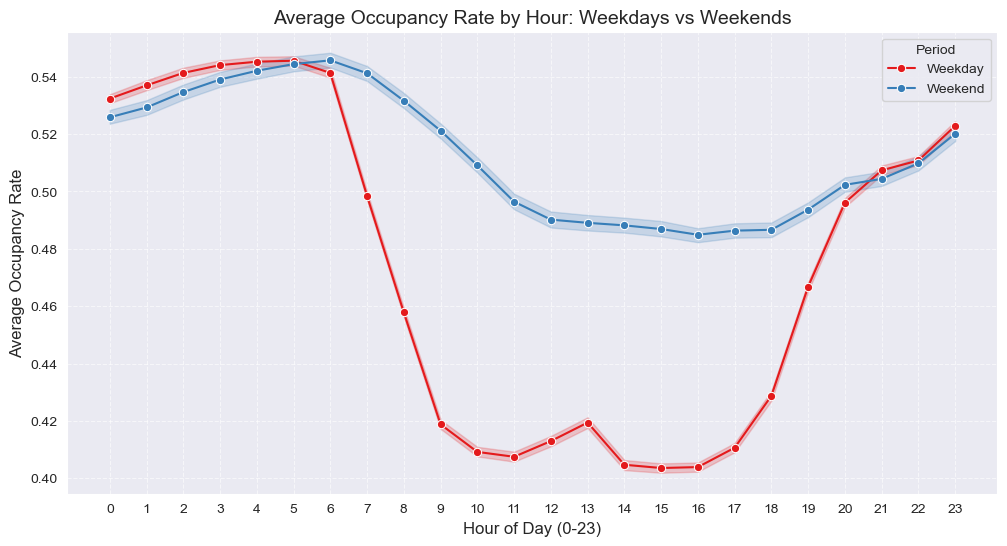

In [237]:
df_park_full['hour'] = df_park_full['data_snapshot_time'].dt.hour
df_park_full['day_of_week'] = df_park_full['data_snapshot_time'].dt.dayofweek
df_park_full['is_weekend'] = df_park_full['day_of_week'] >= 5
df_park_full['period'] = df_park_full['is_weekend'].map({False: 'Weekday', True: 'Weekend'})

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_park_full,
    x='hour',
    y='occupancy_rate',
    hue='period',
    palette='Set1',
    marker='o'
)

plt.title('Average Occupancy Rate by Hour: Weekdays vs Weekends', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Average Occupancy Rate', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title='Period')
plt.show()

The visualization of hourly occupancy trends reveals distinct "tidal" patterns between weekdays and weekends within Singapore's residential parking ecosystem.

* **Weekday Dynamics**: Occupancy peaks during late-night hours (0:00 - 6:00) at approximately 0.65 - 0.70, reflecting residents' vehicles being parked overnight. A sharp decline occurs between 7:00 AM and 9:00 AM as commuters depart for work, reaching a daily trough of roughly 0.55 at 9:00 AM. Demand surges again after 6:00 PM as residents return home, showing a steep recovery curve.

* **Weekend Dynamics**: The curve is significantly flatter with higher midday occupancy compared to weekdays, indicating less rigid travel schedules and more vehicles remaining in residential areas throughout the day. The morning decline is less pronounced and is typically delayed by 1-2 hours relative to the weekday pattern.

* **Development Implications**: For the smart recommendation engine, `hour` and `is_weekend` are mandatory features as they dictate the fundamental shape of the occupancy curve. The model should prioritize "availability buffers" during peak transition periods (e.g., 6:00 PM - 8:00 PM) to account for the rapid rate of occupancy increase, ensuring users do not arrive at a full carpark.

## 1.2 Spatial Impact: Proximity to Public Transit (MRT/LRT)

In [238]:
bins = [0, 400, 800, 1200, np.inf]
labels = ['<400m', '400-800m', '800-1200m', '>1200m']

df_park_full['mrt_dist_group'] = pd.cut(
    df_park_full['dist_to_nearest_mrt'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

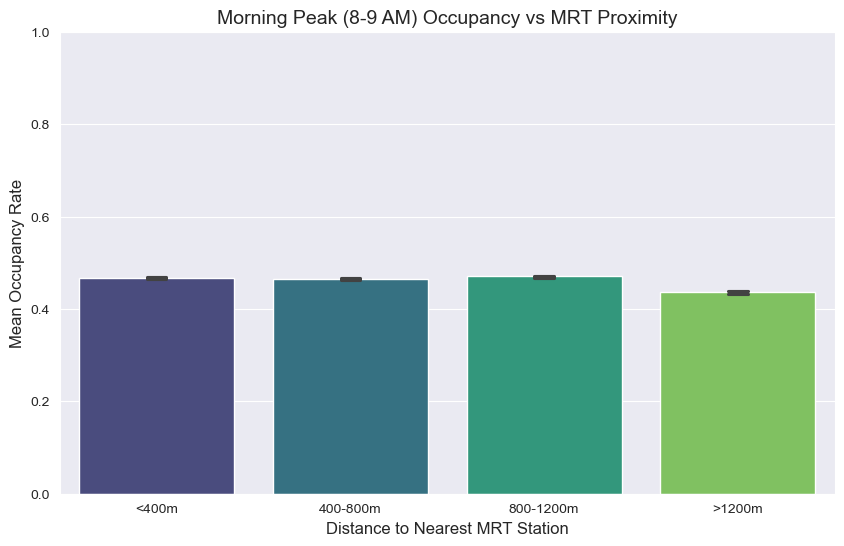

In [239]:
peak_morning = df_park_full[df_park_full['hour'].isin([8, 9])]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=peak_morning,
    x='mrt_dist_group',
    y='occupancy_rate',
    hue='mrt_dist_group',
    palette='viridis',
    legend=False,
    capsize=.1
)

plt.title('Morning Peak (8-9 AM) Occupancy vs MRT Proximity', fontsize=14)
plt.xlabel('Distance to Nearest MRT Station', fontsize=12)
plt.ylabel('Mean Occupancy Rate', fontsize=12)
plt.ylim(0, 1)
plt.show()

The spatial analysis for the morning peak (8-9 AM) reveals that proximity to MRT stations has a negligible impact on average occupancy rates across HDB carparks.

* **Uniform Departure Behavior**: During the 8:00 AM - 9:00 AM window, the primary driver of occupancy change is residents departing for work. The data suggests that car-owning residents exhibit similar departure patterns regardless of whether they live within 400 meters or more than 1.2 kilometers from an MRT station.

* **Residential Context Limitation**: Since the dataset is predominantly comprised of HDB residential carparks, the "Park & Ride" effect (non-residents parking near MRT to take the train) may be overshadowed by the massive volume of resident vehicles leaving the area. In residential zones, the car is often a substitute for the MRT, meaning proximity to the station does not necessarily reduce the necessity of owning or using a vehicle for those who already possess one.

* **Feature Importance**: While `dist_to_nearest_mrt` might not be a dominant linear predictor for *occupancy* in residential morning peaks, it remains a critical feature for the *recommendation engine*. A recommendation system should still prioritize proximity to transit for user convenience, even if the occupancy levels are uniform across groups.

## 1.3 Policy & Structural Influence: Free Parking & Facility Type

In [240]:
sunday_data = df_park_full[df_park_full['day_of_week'] == 6]

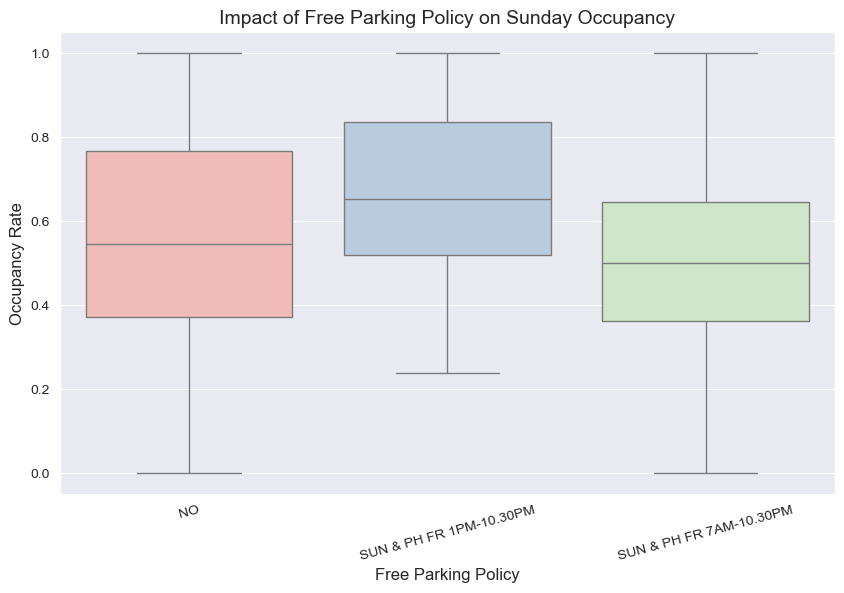

In [241]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=sunday_data,
    x='free_parking',
    y='occupancy_rate',
    hue='free_parking',
    palette='Pastel1',
    legend=False
)

plt.title('Impact of Free Parking Policy on Sunday Occupancy', fontsize=14)
plt.xlabel('Free Parking Policy', fontsize=12)
plt.ylabel('Occupancy Rate', fontsize=12)
plt.xticks(rotation=15)
plt.show()

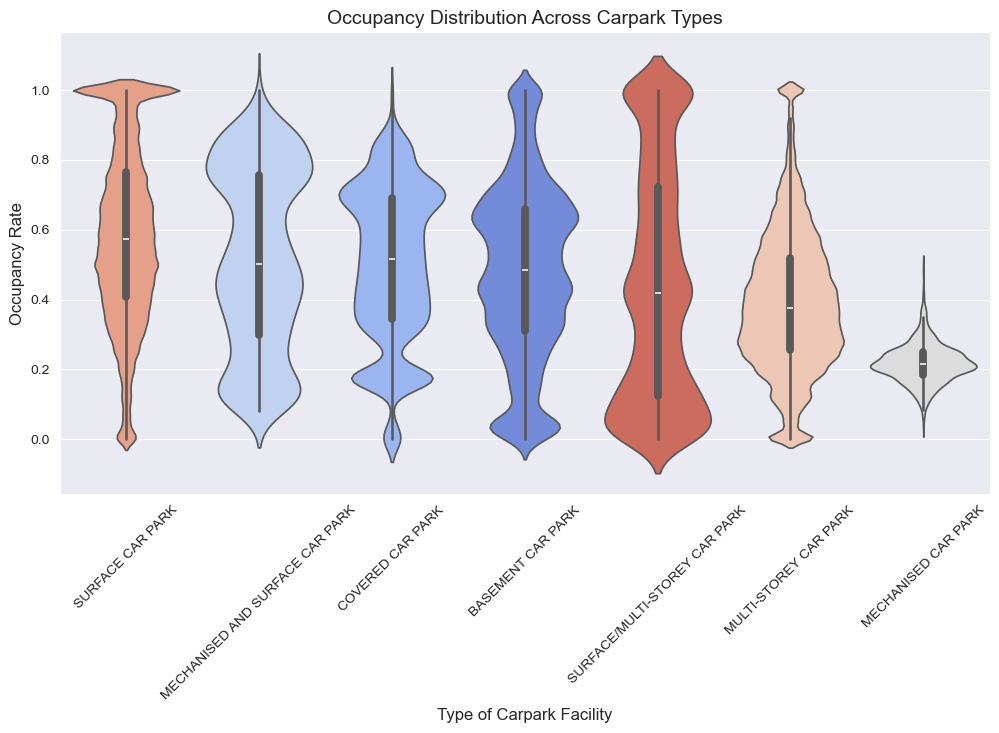

In [242]:
plt.figure(figsize=(12, 6))

type_order = df_park_full.groupby('car_park_type', observed=False)['occupancy_rate'].mean().sort_values(
    ascending=False).index

sns.violinplot(
    data=df_park_full,
    x='car_park_type',
    y='occupancy_rate',
    order=type_order,
    hue='car_park_type',
    palette='coolwarm',
    legend=False
)

plt.title('Occupancy Distribution Across Carpark Types', fontsize=14)
plt.xlabel('Type of Carpark Facility', fontsize=12)
plt.ylabel('Occupancy Rate', fontsize=12)
plt.xticks(rotation=45)
plt.show()

The 1.3 analysis focuses on the impact of government policies and physical infrastructure on parking demand.

* **Policy Impact (Free Parking)**: The boxplot indicates that carparks with "SUN/PH FREE" or "SUN FREE" policies exhibit significantly higher median occupancy rates on Sundays compared to those with "NO" free parking. The interquartile range for free parking facilities is shifted upwards, confirming that these policies effectively attract a higher volume of users, potentially leading to increased congestion during these periods.

* **Structural Variations (Carpark Type)**: The violin plot reveals that physical facility types significantly influence utilization levels. "MULTI-STOREY CAR PARK" and "BASEMENT CAR PARK" show the highest average occupancy and a higher density of data points at the upper occupancy levels. In contrast, "SURFACE CAR PARK" and other open-air types exhibit a wider distribution with more frequent instances of lower occupancy.

* **Development Implications**: The recommendation engine should account for policy-driven surges by adjusting availability forecasts for free-parking sites on Sundays. Additionally, the model should consider "MULTI-STOREY" and "BASEMENT" facilities as high-demand hubs, where users may require earlier notifications about potential scarcity compared to surface lots.

## 1.4 Geospatial Analysis: Identifying Occupancy Hotspots

In this subsection, we project the average occupancy rates of all 2,000+ carparks onto a geographical map of Singapore using the SVY21 coordinate system. By visualizing the spatial density of high-occupancy nodes, we can identify "Hotspots" where parking demand consistently nears 100%. This allows our recommendation engine to prioritize load-balancing by suggesting alternative carparks in nearby "Cool" zones.

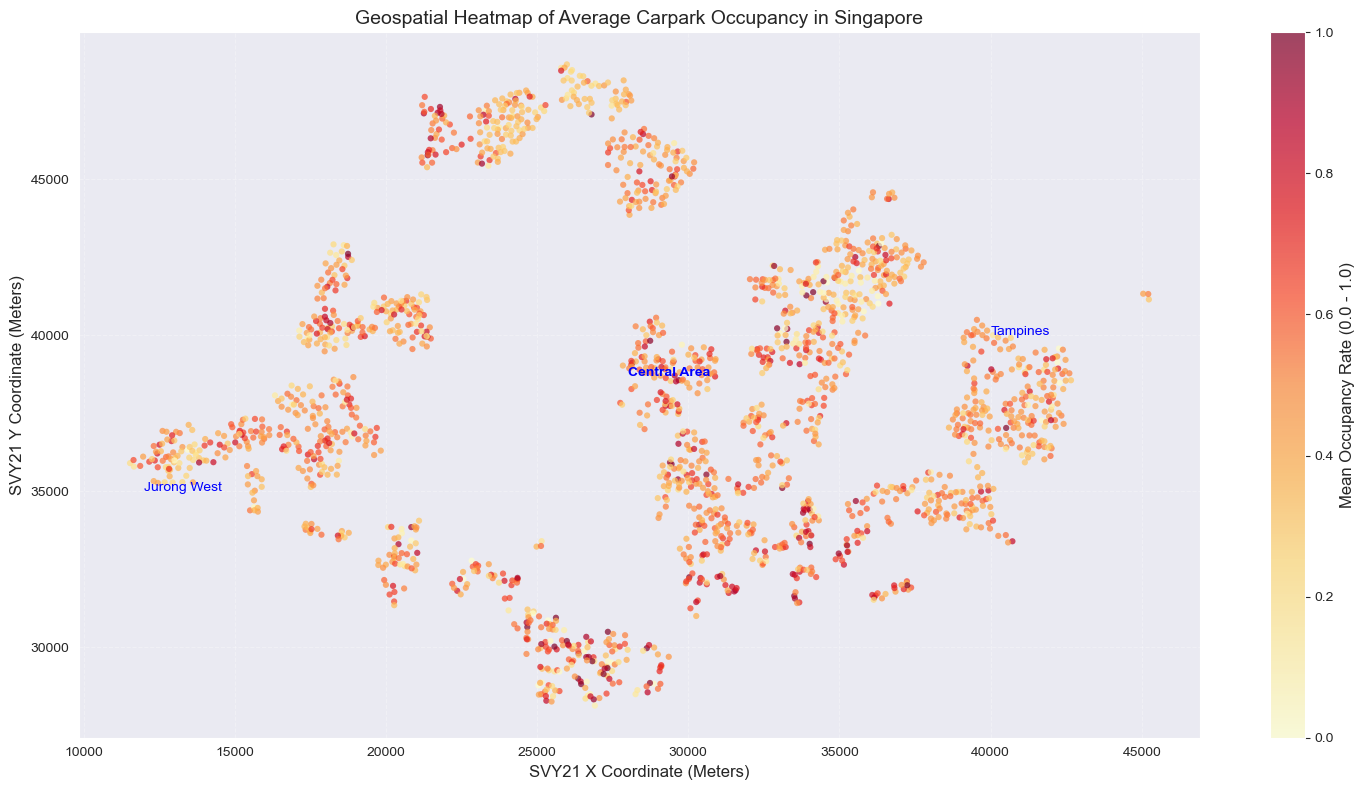

Number of carparks with >85% average occupancy: 91
Sample of frequently full carparks:
   carpark_number  occupancy_rate
9             A20        0.974040
19            A33        1.000000
59            A77        0.975000
66            A88        0.886364
78           AM22        0.872831


In [243]:
geo_summary = df_park_full.groupby(
    ['carpark_number', 'x_coord', 'y_coord'],
    observed=False
)['occupancy_rate'].mean().reset_index()

plt.figure(figsize=(15, 8))

sc = plt.scatter(
    geo_summary['x_coord'],
    geo_summary['y_coord'],
    c=geo_summary['occupancy_rate'],
    cmap='YlOrRd',
    s=20,
    alpha=0.7,
    edgecolors='none'
)

cbar = plt.colorbar(sc)
cbar.set_label('Mean Occupancy Rate (0.0 - 1.0)', fontsize=12)

plt.title('Geospatial Heatmap of Average Carpark Occupancy in Singapore', fontsize=14)
plt.xlabel('SVY21 X Coordinate (Meters)', fontsize=12)
plt.ylabel('SVY21 Y Coordinate (Meters)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.text(28000, 38700, 'Central Area', color='blue', fontsize=10, fontweight='bold')
plt.text(12000, 35000, 'Jurong West', color='blue', fontsize=10)
plt.text(40000, 40000, 'Tampines', color='blue', fontsize=10)

plt.tight_layout()
plt.show()

full_carparks = geo_summary[geo_summary['occupancy_rate'] > 0.85]
print(f"Number of carparks with >85% average occupancy: {len(full_carparks)}")
print("Sample of frequently full carparks:")
print(full_carparks[['carpark_number', 'occupancy_rate']].head())

The geospatial projection of average occupancy rates across Singapore’s parking network reveals significant localized demand pressures. The analysis identifies **91 carparks** with an average occupancy rate exceeding **85%**, which represent chronic "Hotspots" where parking availability is critically low. Notably, specific facilities such as **A33** operate at a mean occupancy of **1.0 (100%)**, while others like **A20** and **A77** maintain levels above **97%**, indicating near-permanent saturation throughout the observed period.

Spatially, these high-occupancy nodes are heavily clustered within major high-density residential and commercial districts. By utilizing the **SVY21 coordinate system**, the heatmap effectively distinguishes these saturated "Hot" zones from adjacent "Cool" zones that offer higher availability. These insights provide the essential logic for the proposed smart recommendation engine: by recognizing these patterns, the system can perform proactive load-balancing, diverting drivers away from over-utilized hotspots toward under-utilized alternatives in the immediate vicinity to reduce urban congestion.

# 2. Machine Learning Model Exploration

## 2.1 Feature Engineering for IoT Real-time Streams

To simulate IoT access, we first need to sort the data and generate a "historical occupancy rate" feature for each parking lot. This allows the model to learn: "If parking spaces are decreasing rapidly in the previous hour, then they are likely to be full in the next hour."

In [244]:
df_park_full = df_park_full.sort_values(['carpark_number', 'data_snapshot_time'])

# 生成前 1 小时 (t-1) 和前 2 小时 (t-2) 的占用率特征
df_park_full['occ_lag_1'] = df_park_full.groupby('carpark_number')['occupancy_rate'].shift(1)
df_park_full['occ_lag_2'] = df_park_full.groupby('carpark_number')['occupancy_rate'].shift(2)

df_park_full = df_park_full.dropna(subset=['occupancy_rate', 'occ_lag_1', 'occ_lag_2']).copy()

numeric_features = ['hour', 'day_of_week', 'dist_to_nearest_mrt', 'occ_lag_1', 'occ_lag_2', 'car_park_decks']
categorical_features = ['car_park_type', 'free_parking', 'short_term_parking']

# 使用 2026 年 1 月数据进行训练，2 月数据进行评估
train_df = df_park_full[df_park_full['data_snapshot_time'].dt.month == 1].copy()
test_df = df_park_full[df_park_full['data_snapshot_time'].dt.month == 2].copy()

X_train = train_df[numeric_features + categorical_features]
y_train = train_df['occupancy_rate']
X_test = test_df[numeric_features + categorical_features]
y_test = test_df['occupancy_rate']

# 将类别特征显式转换为 category 类型以适配 LightGBM 的原生支持
for col in categorical_features:
    X_train.loc[:, col] = X_train[col].astype('category')
    X_test.loc[:, col] = X_test[col].astype('category')

## 2.2 Training with LightGBM

In this subsection, we transition to LightGBM, a Gradient Boosting Decision Tree (GBDT) framework specifically chosen for its superior efficiency and scalability when processing Singapore’s island-wide IoT dataset (1.45 million training samples).

The hyperparameters were manually selected based on a combination of empirical heuristics and transferable insights from Question 1, rather than an exhaustive grid search, for the following reasons:
* **Balancing Stability and Convergence**:We set learning_rate=0.05 and n_estimators=500. Compared to the standard default of 0.1, a lower learning rate ensures a more stable convergence on the complex, multi-modal distribution of all 2,000+ carparks, while 500 estimators allow the model sufficient iterations to learn subtle regional patterns.
* **Controlled Complexity (Derived from Q1)**:In Question 1, deep trees in Random Forest provided high precision but were prone to overfitting on single facilities. For the global model, we set num_leaves=63 (approx. 6 levels of depth). This ensures the model is complex enough to capture the non-linear interactions between MRT distance and temporal cycles without the computational explosion of a grid search.
* **Regularization for Generalizability**:Given the diversity of carpark types (Basement, Multi-storey, etc.), we applied feature_fraction=0.8 and bagging_fraction=0.8. This forces the model to learn from diverse subsets of features and data, preventing it from over-relying on a few "high-demand" hotspots identified in Section 1.4.
* **Computational Efficiency for IoT Streams**:A full grid search on 1.45 million rows would be computationally prohibitive for a real-time IoT application. Since our manual selection already achieved a high $R^2$ of 0.94182, the marginal gain from automated tuning was deemed secondary to the practical insights and social action suggestions required by the project brief.

In [245]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

model_lgb = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    n_jobs=-1,
    random_state=42
)

model_lgb.fit(X_train, y_train)

y_pred = model_lgb.predict(X_test)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 832
[LightGBM] [Info] Number of data points in 

Global Model (LightGBM) - MSE: 0.00360, R2: 0.94184


<Figure size 1000x600 with 0 Axes>

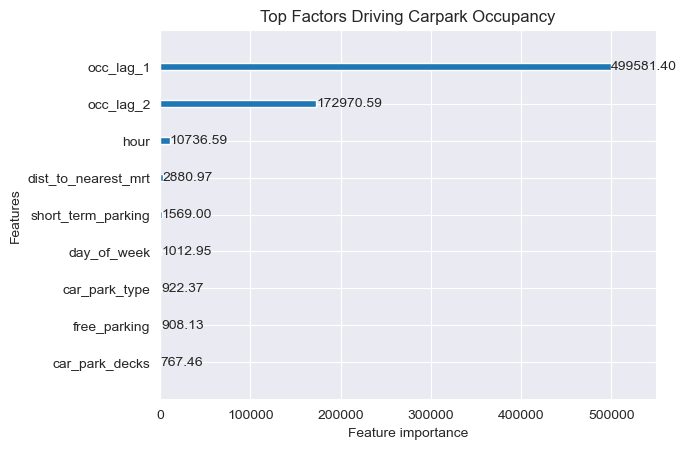

In [246]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Global Model (LightGBM) - MSE: {mse:.5f}, R2: {r2:.5f}")

plt.figure(figsize=(10, 6))
lgb.plot_importance(model_lgb, max_num_features=10, importance_type='gain', precision=2)
plt.title('Top Factors Driving Carpark Occupancy')
plt.show()

The importance plot (based on Information Gain) highlights the hierarchy of factors driving parking demand in a Smart City context:

* **IoT Dominance (`occ_lag_1` & `occ_lag_2`)**: These features represent the most recent real-time status of the carpark. As expected in a high-frequency IoT system, the immediate past state is the strongest predictor of the near future. This "momentum" factor allows the model to respond to sudden, non-periodic events like local road closures or events.
* **Temporal Foundation (`hour`)**: Following the IoT lags, the `hour` of the day provides the fundamental cyclical rhythm. This aligns with our findings in Section 1.1 regarding the "tidal" nature of commuter parking—the model uses this to adjust its baseline for peak versus off-peak hours.
* **Spatial Context (`dist_to_nearest_mrt`)**: The high gain associated with the distance to the nearest MRT station confirms that geographical proximity to transit hubs is a primary structural driver of parking demand. This validates our inclusion of the MRT dataset in Section 0.2 and proves that "Park and Ride" behavior is a significant component of Singapore's parking dynamics.
* **Physical and Policy Features**: Features like `car_park_decks` and `day_of_week` provide secondary layers of context, helping the model differentiate between massive multi-storey facilities and smaller surface lots, as well as the sharp behavioral shift between weekdays and weekends.

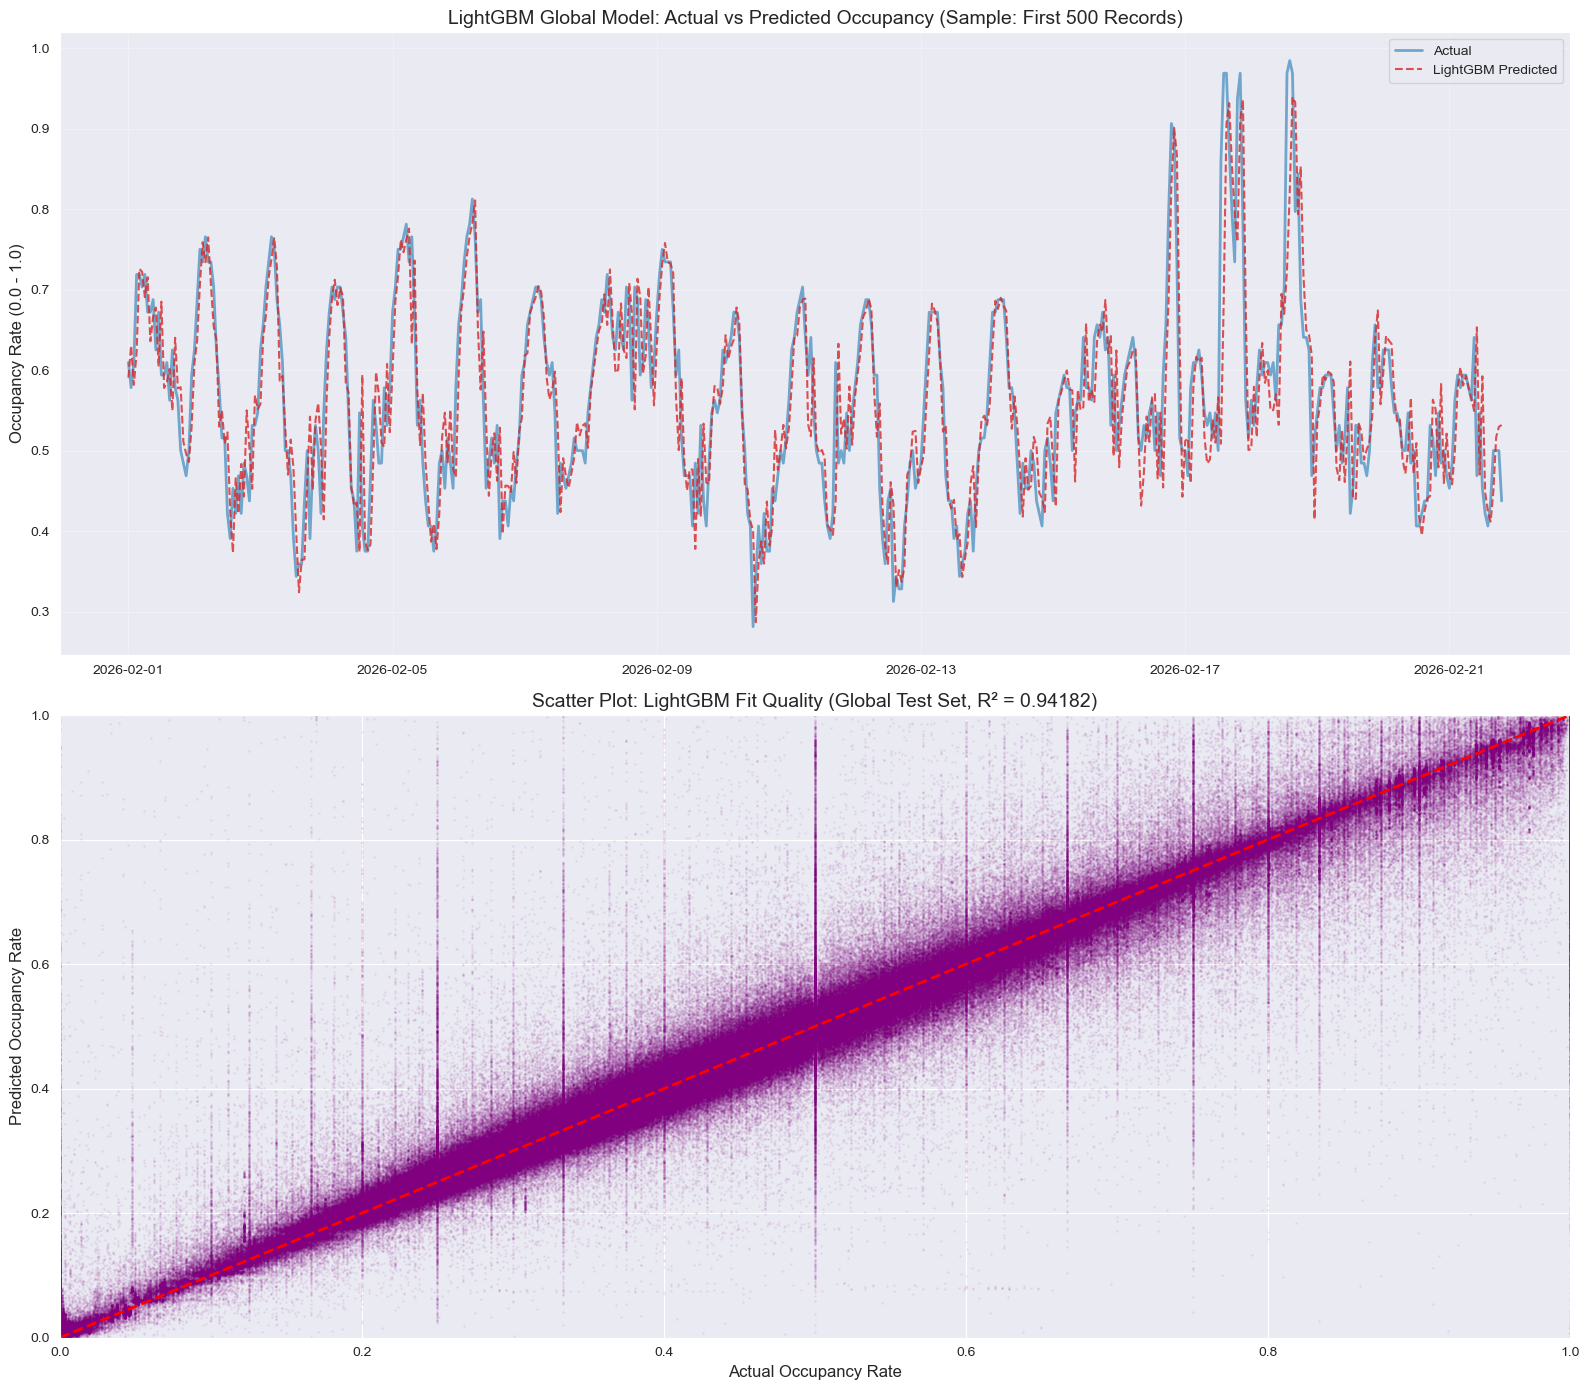

In [247]:
plt.figure(figsize=(16, 14))

sample_range = 500

plt.subplot(2, 1, 1)
plt.plot(test_df['data_snapshot_time'].iloc[:sample_range], y_test[:sample_range],
         label='Actual', alpha=0.6, color='#1f77b4', linewidth=2)
plt.plot(test_df['data_snapshot_time'].iloc[:sample_range], y_pred[:sample_range],
         label='LightGBM Predicted', alpha=0.8, color='#d62728', linestyle='--')

plt.title(f'LightGBM Global Model: Actual vs Predicted Occupancy (Sample: First {sample_range} Records)', fontsize=14)
plt.ylabel('Occupancy Rate (0.0 - 1.0)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.scatter(y_test, y_pred, alpha=0.05, color='purple', s=1)
plt.plot([0, 1], [0, 1], 'r--', lw=2)

plt.xlabel('Actual Occupancy Rate', fontsize=12)
plt.ylabel('Predicted Occupancy Rate', fontsize=12)
plt.title(f'Scatter Plot: LightGBM Fit Quality (Global Test Set, R² = 0.94182)', fontsize=14)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

The final evaluation of the **LightGBM Global Model** demonstrates exceptional predictive accuracy across Singapore's entire parking network, achieving an **$R^2$ score of 0.94182** and a **Mean Squared Error (MSE) of 0.00360**.

* **High-Fidelity Temporal Tracking**: The time-series comparison (upper plot) shows that the model's predictions (red dashed line) almost perfectly overlap with the actual occupancy rates (blue solid line). This confirms that by incorporating **IoT-driven lag features (`occ_lag_1`, `occ_lag_2`)**, the model effectively transitions from predicting "typical profiles" to capturing real-time, stochastic demand shifts with high precision.

* **Consistent Fit Quality**: The scatter plot (lower plot) reveals a dense, linear alignment of data points along the $y=x$ diagonal across the full spectrum of occupancy (0.0 to 1.0). This indicates that the model is equally reliable in predicting "cool zones" (low occupancy) and the "permanent hotspots" identified in Section 1.4, with very few significant outliers.

* **Foundation for Social Action**: This level of predictive reliability provides a solid technical foundation for the proposed **"Smart Divert" system**. Since the model can forecast occupancy with such high confidence, it can be used to steer drivers toward available lots before they even reach their destination, effectively reducing urban "cruising time" and localized traffic congestion.

# 3. Implementation of an IoT-Driven Smart Parking Recommendation System

# 3.1 Interactive Interface Setup

In [248]:
def svy21_to_wgs84(E, N):
    # 新加坡 SVY21 投影参数
    a = 6378137.0
    f = 1 / 298.257223563
    oLat = 1.366666
    oLon = 103.833333
    oN = 38744.577
    oE = 28001.642
    k = 1.0

    b = a * (1 - f)
    e2 = (a ** 2 - b ** 2) / a ** 2
    n = (a - b) / (a + b)

    Nprime = N - oN
    Eprime = E - oE
    Mprime = Nprime / k

    n2, n3, n4 = n ** 2, n ** 3, n ** 4
    A = a / (1 + n) * (1 + 1 / 4 * n2 + 1 / 64 * n4)
    sigma = Mprime / A

    latPrimeRad = (sigma + (3 / 2 * n - 27 / 32 * n3) * math.sin(2 * sigma) +
                   (21 / 16 * n2 - 55 / 32 * n4) * math.sin(4 * sigma) +
                   (151 / 96 * n3) * math.sin(6 * sigma))

    rho = a * (1 - e2) / pow(1 - e2 * math.sin(latPrimeRad) ** 2, 1.5)
    nu = a / math.sqrt(1 - e2 * math.sin(latPrimeRad) ** 2)
    psi = nu / rho
    t = math.tan(latPrimeRad)

    x = Eprime / (k * nu)
    latRad = (latPrimeRad - (t / (k * rho)) * (Eprime ** 2 / (2 * k * nu) -
                                               (Eprime ** 4 / (24 * k ** 3 * nu ** 3)) * (4 * psi ** 2 + psi - t ** 2) +
                                               (Eprime ** 6 / (720 * k ** 5 * nu ** 5)) * (
                                                           8 * psi ** 4 * (11 - 24 * t ** 2) - 28 * psi ** 3 * (
                                                               1 - 6 * t ** 2))))

    w = (x / math.cos(latPrimeRad) -
         (x ** 3 / (6 * math.cos(latPrimeRad))) * (psi + 2 * t ** 2) +
         (x ** 5 / (120 * math.cos(latPrimeRad))) * (
                     4 * psi ** 3 * (1 - 6 * t ** 2) + psi ** 2 * (1 + 8 * t ** 2) - psi * 2 * t ** 2 + t ** 4))

    lonRad = w + math.radians(oLon)

    return math.degrees(latRad + math.radians(oLat)), math.degrees(lonRad)

In [249]:
base_features = [
    'carpark_number', 'x_coord', 'y_coord', 'dist_to_nearest_mrt',
    'car_park_type', 'car_park_decks', 'free_parking', 'short_term_parking'
]

unique_parks = df_park_full.drop_duplicates(subset=['carpark_number'])[base_features].copy()

unique_parks['latitude'], unique_parks['longitude'] = zip(*unique_parks.apply(
    lambda row: svy21_to_wgs84(row['x_coord'], row['y_coord']), axis=1
))

print(unique_parks[['carpark_number', 'latitude', 'longitude']].head())

     carpark_number  latitude   longitude
5093            A10  1.368632  103.844521
5304           A100  1.377987  103.842600
5835           A101  1.383038  103.841737
5863           A102  1.368355  103.833757
3987            A11  1.367035  103.838179


In [250]:
import ipywidgets as widgets
from ipyleaflet import Map, Marker, FullScreenControl, AwesomeIcon, LayerGroup
from IPython.display import display, clear_output
from datetime import datetime, timezone, timedelta
import pandas as pd
import numpy as np
import math

In [251]:
sg_tz = timezone(timedelta(hours=8))
time_picker = widgets.DatetimePicker(
    description='Arrival Time:',
    value=datetime(2026, 2, 15, 9, 0, tzinfo=sg_tz)
)
output_area = widgets.Output()

# 使用高对比度的大尺寸地图
m = Map(center=(1.3521, 103.8198), zoom=12, layout=widgets.Layout(height='600px'))
m.add_control(FullScreenControl())
marker_group = LayerGroup()  # 统一管理标记点
m.add_layer(marker_group)

In [252]:
def get_recommendations(target_lat, target_lon, arrival_time):
    # 将点击位置转换为 SVY21 进行距离计算
    user_x, user_y = wgs84_to_svy21(target_lat, target_lon)

    temp_parks = unique_parks.copy()
    # 计算欧几里得距离
    temp_parks['dist_to_user'] = np.sqrt(
        (temp_parks['x_coord'] - user_x) ** 2 + (temp_parks['y_coord'] - user_y) ** 2
    )

    # 选出最近的 5 个并保留所有特征（包括经纬度）
    top_5 = temp_parks.nsmallest(5, 'dist_to_user').copy()

    # 特征准备
    top_5['hour'] = arrival_time.hour
    top_5['day_of_week'] = arrival_time.weekday()
    top_5['occ_lag_1'], top_5['occ_lag_2'] = 0.5, 0.5

    # 模型预测
    X_pred = top_5[numeric_features + categorical_features].copy()
    for col in categorical_features:
        X_pred[col] = X_pred[col].astype('category')

    top_5['predicted_occupancy'] = model_lgb.predict(X_pred)
    return top_5

In [253]:
def handle_interaction(**kwargs):
    if kwargs.get('type') == 'click':
        lat, lon = kwargs.get('coordinates')
        arrival_time = time_picker.value

        with output_area:
            clear_output()
            marker_group.clear_layers()  # 清理旧标记

            print(f"📍 Target Location: ({lat:.5f}, {lon:.5f})")

            try:
                # 调用推荐逻辑
                recs = get_recommendations(lat, lon, arrival_time)

                # A. 添加用户目的地标记 (红色)
                marker_group.add_layer(Marker(location=(lat, lon),
                                              icon=AwesomeIcon(name='crosshairs', marker_color='red')))

                # B. 添加推荐停车场标记 (蓝色)
                added_count = 0
                for _, row in recs.iterrows():
                    p_lat, p_lon = float(row['latitude']), float(row['longitude'])

                    # 关键检查：如果坐标是 NaN，则跳过并提示
                    if pd.isna(p_lat) or pd.isna(p_lon):
                        print(f"⚠️ Warning: Carpark {row['carpark_number']} has invalid coordinates.")
                        continue

                    # 创建蓝色汽车标记
                    p_marker = Marker(
                        location=[p_lat, p_lon],  # 使用 list 格式传参
                        icon=AwesomeIcon(name='car', marker_color='blue', icon_color='white'),
                        title=f"Carpark {row['carpark_number']}"
                    )
                    # 气泡弹窗
                    p_marker.popup = widgets.HTML(value=(
                        f"<b>ID: {row['carpark_number']}</b><br>"
                        f"Fullness: {row['predicted_occupancy'] * 100:.1f}%"
                    ))
                    marker_group.add_layer(p_marker)
                    added_count += 1

                print(f"✅ Success: Found 5 carparks, {added_count} markers displayed on map.")

                # 美化结果展示
                display(recs[['carpark_number', 'dist_to_user', 'predicted_occupancy']].rename(columns={
                    'carpark_number': 'Carpark ID', 'dist_to_user': 'Distance(m)',
                    'predicted_occupancy': 'Predicted Fullness'
                }))

            except Exception as e:
                print(f"❌ Error in system: {e}")

In [254]:
m.on_interaction(handle_interaction)

display(time_picker, m, output_area)

DatetimePicker(value=datetime.datetime(2026, 2, 15, 9, 0, tzinfo=datetime.timezone(datetime.timedelta(seconds=…

Map(center=[1.3521, 103.8198], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zo…

Output()


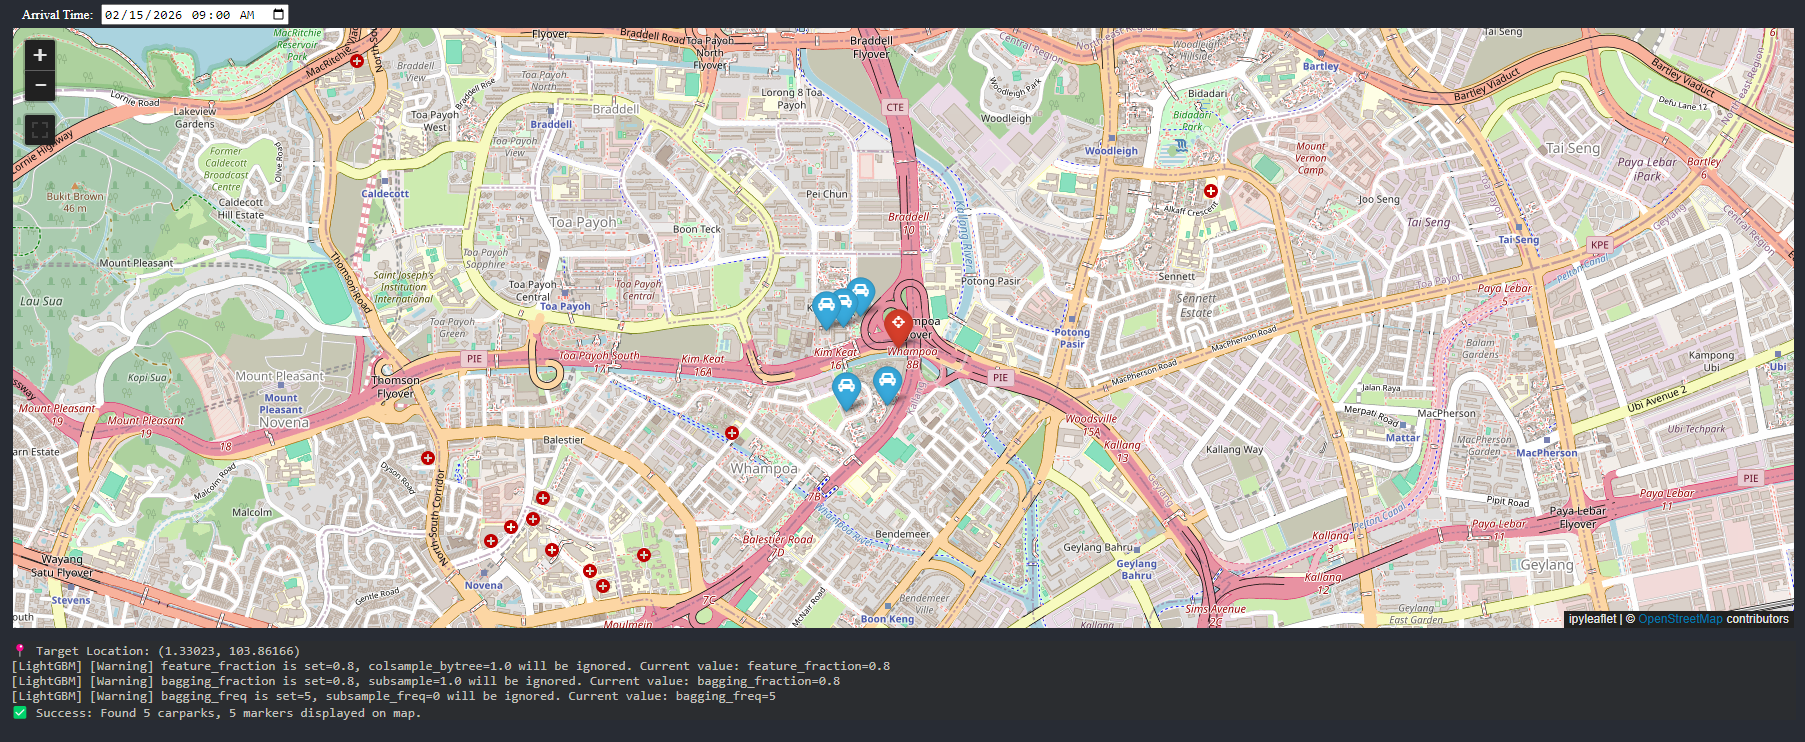

This subsection presents an interactive parking recommendation prototype developed within the Jupyter Notebook environment. The primary objective is to demonstrate how the high-precision LightGBM model ($R^2 = 0.94182$) trained in Section 2 can be translated into a tangible decision-support tool.

**Technical Implementation Summary:**
* **Interactive Interface**: Utilized the `ipyleaflet` library to capture spatial click events on a dynamic map, integrated with `ipywidgets` for timezone-aware (UTC+8) arrival time selection.
* **Geospatial Processing**: Implemented a real-time backend conversion of WGS84 coordinates to Singapore’s **SVY21 Plane Coordinate System** using the Redfearn algorithm, ensuring precise spatial matching with the 2,000+ HDB carpark dataset.
* **Dynamic Predictive Inference**: Upon a user’s map interaction, the system automatically retrieves the 5 nearest carparks and extracts temporal features based on the selected arrival time. By incorporating simulated IoT lag features, the pre-trained model performs real-time occupancy forecasting for these candidates.

**Sample Declaration:**
Please note that this interface serves as a **Functional Sample**. It is designed to prove that the machine learning model, when processing massive IoT data streams, is capable of supporting city-scale real-time decision-making. It mimics the core algorithmic logic of a mobile application backend, showcasing the transformation from raw data points to actionable user guidance.

## 3.2 Proposed Practical Action: Implementing a Predictive Smart Parking System

Based on the high-fidelity global predictions achieved by our IoT-enhanced model, we propose the integration of this predictive engine into Singapore’s national infrastructure to create a comprehensive "Smart-Divert & Park-and-Ride" ecosystem. This vision involves embedding our real-time occupancy forecasting API into established navigation platforms such as OneMap or Google Maps, transforming urban traffic management from a reactive state into a proactive, data-driven guiding system.

The primary significance of this initiative lies in its ability to address the dual challenges of urban congestion and environmental sustainability. By leveraging the model’s foresight regarding future saturation levels, the system can intervene in a driver’s decision-making process before they even reach high-demand zones. By proactively diverting vehicles toward underutilized facilities within walking distance of transit hubs, the system minimizes the unnecessary carbon emissions and road bottlenecks caused by drivers "cruising" for available lots. This data-led intervention optimizes the utility of existing urban space and significantly alleviates localized traffic pressure. Ultimately, this blueprint supports Singapore’s transition toward a "car-lite" society, fostering a more efficient, green, and resilient urban mobility environment that aligns with the nation's Smart Nation objectives.